In [25]:
import pandas as pd
import os
import glob
import matplotlib.pyplot as plt
import re

In [26]:
parent_dir = "../results/mechanics_pushing/"

# Find all 'cells_position_time.csv' files under any subdirectory of parent_dir
csv_files = glob.glob(os.path.join(parent_dir, "*", "cells_position_time.csv"))

# Dictionary to store results
results = {}


In [27]:

for csv_file in csv_files:
    try:
        df = pd.read_csv(csv_file)

        # Extract x positions for id 0 and 1
        x0 = df[df['id'] == 0]['x'].reset_index(drop=True)
        x1 = df[df['id'] == 1]['x'].reset_index(drop=True)
        dt = df[df['id'] == 0]['dt'].reset_index(drop=True)

        # Compute absolute difference
        pc_dist_dt = pd.DataFrame({
            'dt': dt,
            'dx': abs(x0 - x1)
        })

        # Use last folder name as the key (for legend)
        last_folder = os.path.basename(os.path.dirname(csv_file))
        parts = last_folder.split("_")
        dt_val = re.sub(r'^0', '0,',  parts[-2])
        adh_val = re.sub(r'^0', '0.',  parts[-1])
        label = f"dt = {dt_val}, adh = {adh_val}"
        results[label] = pc_dist_dt

        print(f"Processed: {last_folder}")

    except Exception as e:
        print(f"Error processing {csv_file}: {e}")

Processed: mechanics_pushing_001_004
Processed: mechanics_pushing_01_004
Processed: mechanics_pushing_01_04
Processed: mechanics_pushing_001_04


dt = 0,01, adh = 0.04
dt = 0,1, adh = 0.04
dt = 0,1, adh = 0.4
dt = 0,01, adh = 0.4


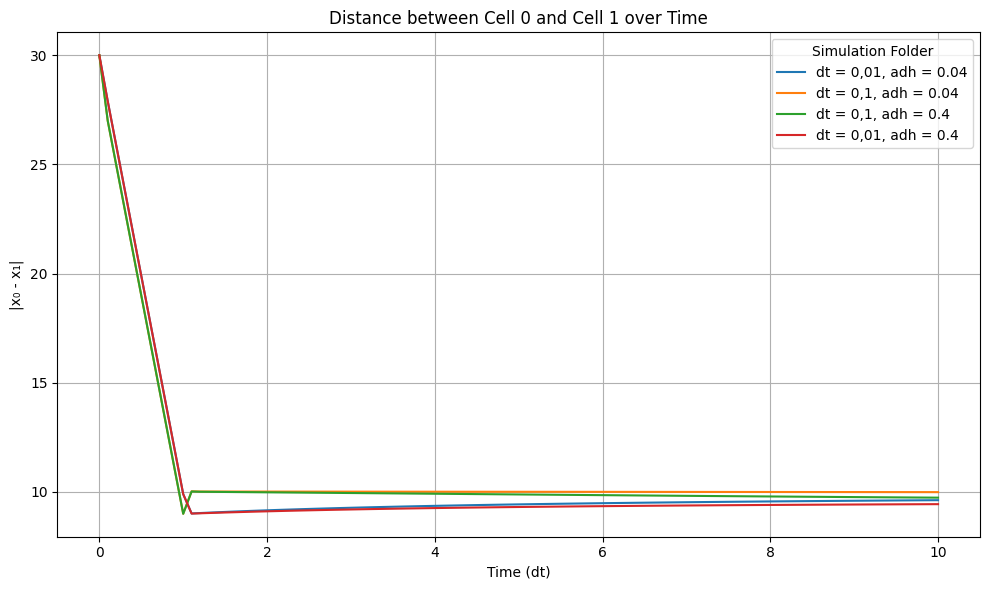

In [28]:
plt.figure(figsize=(10, 6))
for label, df in results.items():
    print(label)
    plt.plot(df['dt'], df['dx'], label=label)

plt.xlabel("Time (dt)")
plt.ylabel("|x₀ - x₁|")
plt.title("Distance between Cell 0 and Cell 1 over Time")
plt.legend(title="Simulation Folder")
plt.grid(True)
plt.tight_layout()
plt.show()